# Probabilistic Forecasting: Bootstrapped Residuals

Forecasting intervals with bootstrapped residuals is a method used to estimate the uncertainty in predictions by resampling past prediction errors (residuals). The goal is to generate prediction intervals that capture the variability in the forecast, giving a range of possible future values instead of just a single point estimate.

The error of a one-step-ahead forecast is defined as the difference between the actual value and the predicted value ($e_t = y_t - \hat{y}_{t|t-1}$). By assuming that future errors will be similar to past errors, it is possible to simulate different predictions by taking samples from the collection of errors previously seen in the past (i.e., the residuals) and adding them to the predictions.

<p style="text-align: center">
<img src="../img/diagram-bootstrapping-prediction-intervals.png" style="width: 500px;">
<br>
<font size="2.5"> <i>Diagram of the bootstrapping prediction process.</i></font>
</p>

Repeatedly performing this process creates a collection of slightly different predictions, which represent the distribution of possible outcomes due to the expected variance in the forecasting process.

<p style="text-align: center">
<img src="../img/diagram-bootstrapping-prediction-intervals-2.png" style="width: 500px;">
<br>
<font size="2.5"> <i>Bootstrapping predictions.</i></font>
</p>

Using the outcome of the bootstrapping process, a prediction interval with a nominal coverage of $1 - \alpha$ (for example, $\alpha = 0.2$ for an 80% interval) is obtained by calculating the $\alpha/2$ and $1 - \alpha/2$ quantiles of the bootstrapped predictions at each forecasting horizon.

<p style="text-align: center">
<video width="450" 
       autoplay 
       muted 
       loop 
       playsinline 
       style="border-radius: 8px; border: 1px solid #e0e0e0;">
    <source src="../img/probabilistic-forecasting-bootstrapping.mp4" type="video/mp4">
</video>
<br>
<font size="2.5"> <i>Animation of probabilistic bootstrapping prediction process.</i></font>
</p>

Alternatively, it is also possible to fit a parametric distribution to the bootstrapped predictions of each forecast horizon (see the `predict_dist` method at the end of this guide). 

One of the main advantages of this strategy is that it requires only a single model to estimate any interval. However, performing hundreds or thousands of bootstrapping iterations can be computationally expensive and may not always be feasible.

The [conformal prediction](../user_guides/probabilistic-forecasting-conformal-prediction.html), [quantile regression](../user_guides/probabilistic-forecasting-quantile-regression.html) and [conformal calibration](../user_guides/probabilistic-forecasting-conformal-calibration.html) user guides reuse the data, partitions and forecaster of this guide, so the intervals obtained with each method can be compared on the same test set.

<div class="admonition note" name="html-admonition" style="background: rgba(0,191,191,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00bfa5; border-color: #00bfa5; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00bfa5;"></i>
    <b style="color: #00bfa5;">&#128161; Tip</b>
</p>

<p>For more examples on how to use probabilistic forecasting, check out the following articles:</p>
<ul>
    <li>
        <a href="https://cienciadedatos.net/documentos/py42-probabilistic-forecasting" target="_blank">
            Probabilistic forecasting with machine learning
        </a>
    </li>
    <li>
        <a href="https://cienciadedatos.net/documentos/py60-probabilistic-forecasting-prediction-intervals-multi-step-forecasting" target="_blank">
            Probabilistic forecasting: prediction intervals for multi-step time series forecasting
        </a>
    </li>
    <li>
        <a href="../faq/probabilistic-forecasting-crps-score.html" target="_blank">
            Continuous Ranked Probability Score (CRPS) in probabilistic forecasting
        </a>
    </li>
</ul>

</div>

## Libraries and data

In [1]:
# Data processing
# ==============================================================================
import numpy as np
import pandas as pd
from skforecast.datasets import fetch_dataset
from pprint import pprint

# Plots
# ==============================================================================
import matplotlib.pyplot as plt
from skforecast.plot import (
    set_dark_theme,
    plot_residuals,
    plot_prediction_distribution,
    plot_prediction_intervals
)

# Modelling and Forecasting
# ==============================================================================
from lightgbm import LGBMRegressor
from skforecast.recursive import ForecasterRecursive
from skforecast.preprocessing import RollingFeatures, CalendarFeatures
from skforecast.model_selection import TimeSeriesFold, backtesting_forecaster
from skforecast.metrics import calculate_coverage, winkler_score
from scipy.stats import norm

# Configuration
# ==============================================================================
import warnings
warnings.filterwarnings('once')

In [2]:
# Data download
# ==============================================================================
data = fetch_dataset(name='bike_sharing', raw=False)
data = data[['users', 'temp', 'hum', 'windspeed', 'holiday']]
data = data.loc['2011-04-01 00:00:00':'2012-10-20 23:00:00', :].copy()
data.head(3)

╭───────────────────────────────── bike_sharing ──────────────────────────────────╮
│ Description:                                                                    │
│ Hourly usage of the bike share system in the city of Washington D.C. during the │
│ years 2011 and 2012. In addition to the number of users per hour, information   │
│ about weather conditions and holidays is available.                             │
│                                                                                 │
│ Source:                                                                         │
│ Fanaee-T,Hadi. (2013). Bike Sharing Dataset. UCI Machine Learning Repository.   │
│ https://doi.org/10.24432/C5W894.                                                │
│                                                                                 │
│ URL:                                                                            │
│ https://raw.githubusercontent.com/skforecast/skforecast-                        │
│ datasets/main/data/bike_sharing_dataset_clean.csv                               │
│                                                                                 │
│ Shape: 17544 rows x 11 columns                                                  │
╰─────────────────────────────────────────────────────────────────────────────────╯

,users,temp,hum,windspeed,holiday
date_time,,,,,
2011-04-01 00:00:00,6.0,10.66,100.0,11.0014,0.0
2011-04-01 01:00:00,4.0,10.66,100.0,11.0014,0.0
2011-04-01 02:00:00,7.0,10.66,93.0,12.9980,0.0


Additional features are created based on calendar information: month, week, day of the week and hour. These variables are cyclical (hour 23 is as close to hour 0 as hour 1 is), so they are encoded with sine and cosine transformations that preserve this continuity.

The [`CalendarFeatures`](https://skforecast.org/latest/api/preprocessing#skforecast.preprocessing._calendar.CalendarFeatures) transformer is passed to the forecaster through the `calendar_features` argument. In this way, the calendar features are generated automatically from the datetime index during both training and prediction, and only the remaining exogenous variables (weather and holidays) have to be provided. For more details, see the [calendar features user guide](../user_guides/calendar-features.html).

In [3]:
# Calendar features (cyclical encoding)
# ==============================================================================
calendar_transformer = CalendarFeatures(
                           features = ['month', 'week', 'day_of_week', 'hour'],
                           encoding = 'cyclical'
                       )
exog_features = ['holiday', 'hum', 'temp', 'windspeed']

# Preview of the features that the forecaster creates internally
calendar_transformer.fit_transform(data[['users']]).head(3)

,users,month_sin,month_cos,week_sin,week_cos,day_of_week_sin,day_of_week_cos,hour_sin,hour_cos
date_time,,,,,,,,,
2011-04-01 00:00:00,6.0,0.866025,-0.5,0.999561,0.029633,-0.433884,-0.900969,0.000000,1.000000
2011-04-01 01:00:00,4.0,0.866025,-0.5,0.999561,0.029633,-0.433884,-0.900969,0.258819,0.965926
2011-04-01 02:00:00,7.0,0.866025,-0.5,0.999561,0.029633,-0.433884,-0.900969,0.500000,0.866025


In [4]:
# Split train-validation-test
# ==============================================================================
end_train = '2012-06-30 23:59:00'
end_validation = '2012-10-01 23:59:00'
data_train = data.loc[: end_train, :]
data_val   = data.loc[end_train:end_validation, :]
data_test  = data.loc[end_validation:, :]

print(f"Dates train      : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Dates validation : {data_val.index.min()} --- {data_val.index.max()}  (n={len(data_val)})")
print(f"Dates test       : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")

Dates train      : 2011-04-01 00:00:00 --- 2012-06-30 23:00:00  (n=10968)
Dates validation : 2012-07-01 00:00:00 --- 2012-10-01 23:00:00  (n=2232)
Dates test       : 2012-10-02 00:00:00 --- 2012-10-20 23:00:00  (n=456)


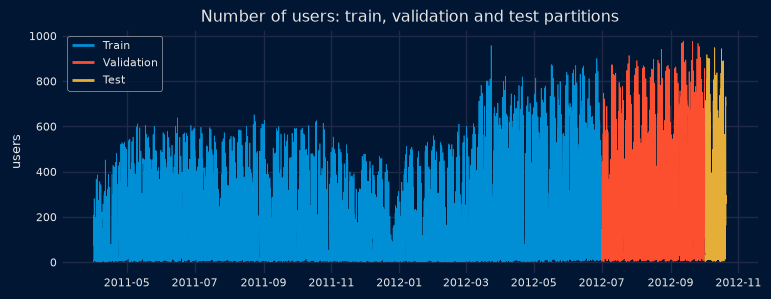

In [5]:
# Plot partitions
# ==============================================================================
# Theme used by all the plots of this guide
set_dark_theme(custom_style={'lines.linewidth': 0.5, 'font.size': 8})

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(data_train['users'], label='Train')
ax.plot(data_val['users'], label='Validation')
ax.plot(data_test['users'], label='Test')
ax.set_ylabel('users')
ax.set_title('Number of users: train, validation and test partitions')
legend = ax.legend()
for line in legend.get_lines():
    line.set_linewidth(2)

The following helper function is used throughout this guide to evaluate the predicted intervals with the metrics described in the [metrics user guide](../user_guides/probabilistic-forecasting-metrics.html): the **empirical coverage** (proportion of true values inside the interval, [`calculate_coverage`](https://skforecast.org/latest/api/metrics#skforecast.metrics.calculate_coverage)), the **area** (sum of the widths of the intervals) and the **Winkler score** (width plus a penalty for each observation outside the interval, [`winkler_score`](https://skforecast.org/latest/api/metrics#skforecast.metrics.winkler_score); the lower the better).

In [6]:
# Function to evaluate predicted intervals
# ==============================================================================
def evaluate_predicted_intervals(predictions: pd.DataFrame, y_true: pd.Series) -> None:
    """
    Print the empirical coverage, the area and the Winkler score of 80% intervals.
    """
    lower_bound = predictions['lower_bound']
    upper_bound = predictions['upper_bound']
    coverage = calculate_coverage(
                   y_true      = y_true,
                   lower_bound = lower_bound,
                   upper_bound = upper_bound
               )
    area = (upper_bound - lower_bound).sum()
    winkler = winkler_score(
                  y_true      = y_true,
                  lower_bound = lower_bound,
                  upper_bound = upper_bound,
                  alpha       = 0.2  # 1 - nominal coverage (80%)
              )
    print(f'Empirical coverage of the interval: {round(100 * coverage, 2)} %')
    print(f'Area of the interval: {round(area, 2)}')
    print(f'Winkler score: {round(winkler, 2)}')

## Intervals with in-sample residuals

By default, prediction intervals are built from in-sample residuals, that is, the errors the model makes when predicting the same data it was trained on. This is the case both when calling [`predict_interval()`](https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.predict_interval) and when running a [backtesting](../user_guides/backtesting.html) procedure. These residuals are always available, since they are computed when the forecaster is trained. However, a model always fits its training data better than data it has never seen. As a result, in-sample residuals tend to be smaller than the errors the model will make on new data, and the intervals built from them are often too narrow (overly optimistic): they contain the true values less often than expected.

A [`ForecasterRecursive`](https://skforecast.org/latest/api/forecasterrecursive) is created using a LightGBM regressor. As predictors, it uses the number of users in the previous 3 hours (lags 1, 2 and 3), the values around the same hour of the previous day (lags 23, 24 and 25) and of the previous week (lags 167, 168 and 169), the mean of the last 72 hours ([`RollingFeatures`](https://skforecast.org/latest/api/preprocessing#skforecast.preprocessing._preprocessing.RollingFeatures)), the calendar features and the exogenous variables. The forecaster is trained with the training and validation data.

In [7]:
# Create and fit forecaster
# ==============================================================================
params = {
    "max_depth": 7,
    "n_estimators": 300,
    "learning_rate": 0.06,
    "verbose": -1,
    "random_state": 15926
}
lags = [1, 2, 3, 23, 24, 25, 167, 168, 169]
window_features = RollingFeatures(stats=["mean"], window_sizes=24 * 3)

forecaster = ForecasterRecursive(
                 estimator         = LGBMRegressor(**params),
                 lags              = lags,
                 window_features   = window_features,
                 calendar_features = calendar_transformer
             )

forecaster.fit(
    y    = data.loc[:end_validation, 'users'],
    exog = data.loc[:end_validation, exog_features],
    store_in_sample_residuals = True
)

By default, the `store_in_sample_residuals` argument of the [`fit()`](https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.fit) method is set to `False` to speed up the training process. To store in-sample residuals without retraining the model, you can call the [`set_in_sample_residuals()`](https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.set_in_sample_residuals) method and pass the training data or set `store_in_sample_residuals` to `True` when fitting the model.

In [8]:
# Store in-sample residuals in case store_in_sample_residuals = False
# ==============================================================================
forecaster.set_in_sample_residuals(
    y    = data.loc[:end_validation, 'users'],
    exog = data.loc[:end_validation, exog_features]
)

In [9]:
# In-sample residuals stored with set_in_sample_residuals()
# ==============================================================================
print("Number of residuals stored:", len(forecaster.in_sample_residuals_))
forecaster.in_sample_residuals_

Number of residuals stored: 10000


array([ 38.2102196 ,  -4.28475005, -29.33611358, ...,  -4.04491958,
       -38.87536687,  -6.27403615], shape=(10000,))

To limit memory usage, the forecaster stores a maximum of 10,000 residuals. If the training set is larger, as in this case, a random sample of the residuals is kept.

Next, the [`backtesting_forecaster()`](https://skforecast.org/latest/api/model_selection#skforecast.model_selection._validation.backtesting_forecaster) function is used to estimate the prediction intervals for the entire test set. The following arguments are required to use this function:

+ `use_in_sample_residuals`: If `True`, the in-sample residuals are used to compute the prediction intervals. Since these residuals are obtained from the training set, they are always available, but usually lead to overoptimistic intervals. If `False`, the out-of-sample residuals are used to calculate the prediction intervals. These residuals are obtained from the validation set and are only available if the [`set_out_sample_residuals()`](https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.set_out_sample_residuals) method has been called. It is recommended to use out-of-sample residuals to achieve the desired coverage.

+ `interval`: The quantiles used to calculate the prediction intervals. For example, if the quantiles 0.1 and 0.9 are used, the resulting prediction intervals will have a nominal coverage of 80%.

+ `interval_method`: The method used to calculate the prediction intervals. Available options are `'bootstrapping'` and `'conformal'`. In this guide, the `bootstrapping` method is used.

+ `use_binned_residuals`: If `True`, the residuals are selected according to the range of the predicted value (binned residuals). This option is explained in a later section; for now, it is set to `False`.

+ `n_boot`: The number of bootstrap samples to be used in estimating the prediction intervals. The larger the number of samples, the more accurate the prediction intervals will be, but the longer the calculation will take. In this guide, 150 samples are used to keep the execution time short (the default value is 250).

In [10]:
# Backtesting with prediction intervals in test data using in-sample residuals
# ==============================================================================
cv_test = TimeSeriesFold(
              steps              = 24,
              initial_train_size = len(data.loc[:end_validation]),
              refit              = False
          )

metric, predictions = backtesting_forecaster(
                          forecaster              = forecaster,
                          y                       = data['users'],
                          exog                    = data[exog_features],
                          cv                      = cv_test,
                          metric                  = 'mean_absolute_error',
                          interval                = [0.1, 0.9],  # 80% prediction interval
                          interval_method         = 'bootstrapping',
                          n_boot                  = 150,
                          use_in_sample_residuals = True,  # Use in-sample residuals
                          use_binned_residuals    = False
                      )
predictions.head(5)

100%|██████████| 19/19 [00:00<00:00, 81.47it/s]

,fold,pred,lower_bound,upper_bound
2012-10-02 00:00:00,0,59.806858,33.935867,80.158493
2012-10-02 01:00:00,0,18.736429,-6.017183,54.656118
2012-10-02 02:00:00,0,8.343854,-17.411844,38.504087
2012-10-02 03:00:00,0,5.829008,-18.563124,39.106756
2012-10-02 04:00:00,0,9.904088,-12.436715,55.249514


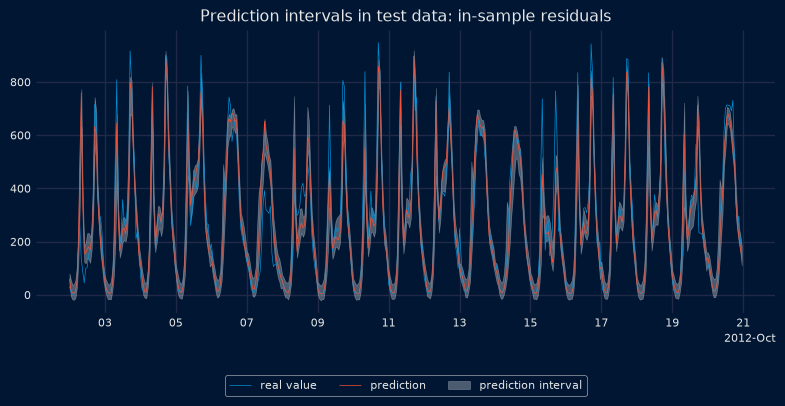

Empirical coverage of the interval: 60.75 %
Area of the interval: 42972.89
Winkler score: 309.76


In [11]:
# Plot intervals
# ==============================================================================
fig, ax = plt.subplots(figsize=(8.5, 3.5))
plot_prediction_intervals(
    predictions         = predictions,
    y_true              = data_test,
    target_variable     = "users",
    title               = "Prediction intervals in test data: in-sample residuals",
    ax                  = ax,
    kwargs_fill_between = {'color': 'white', 'alpha': 0.3, 'zorder': 1}
)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3)
plt.show()

# Coverage, area and Winkler score of the intervals (on test data)
# ==============================================================================
evaluate_predicted_intervals(predictions=predictions, y_true=data_test['users'])

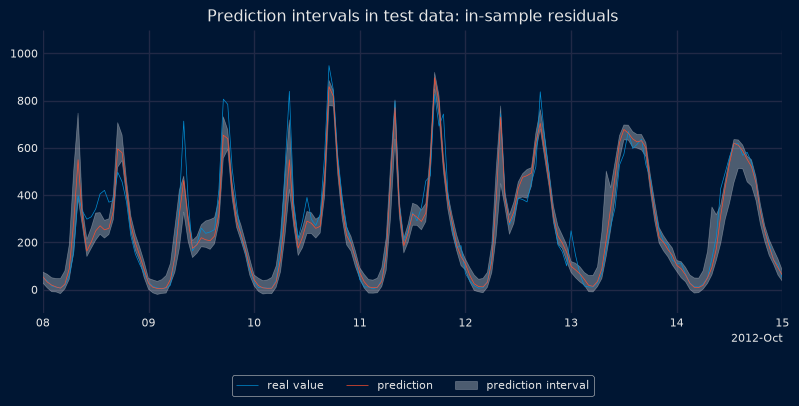

In [12]:
# Plot intervals zoomed in on one week of the test set
# ==============================================================================
zoom_window = ["2012-10-08 00:00:00", "2012-10-15 00:00:00"]
ylim_zoom = (-100, 1100)  # Same y-axis limits in all the zoomed plots

fig, ax = plt.subplots(figsize=(8.5, 3.5))
plot_prediction_intervals(
    predictions         = predictions,
    y_true              = data_test,
    target_variable     = "users",
    initial_x_zoom      = zoom_window,
    title               = "Prediction intervals in test data: in-sample residuals",
    ax                  = ax,
    kwargs_fill_between = {'color': 'white', 'alpha': 0.3, 'zorder': 1}
)
ax.set_ylim(ylim_zoom)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3)
plt.show()

The prediction intervals exhibit overconfidence: they tend to be excessively narrow, resulting in an empirical coverage (around 61%) far below the nominal coverage (80%). This happens because in-sample residuals tend to overestimate the predictive capacity of the model. In the zoomed view of one week, the interval is a thin band around the predictions that frequently misses the observed peaks.

In [13]:
# Store results for later comparison
# ==============================================================================
predictions_in_sample_residuals = predictions.copy()

## Out-of-sample residuals (non-conditioned on predicted values)

To address the issue of overoptimistic intervals, it is possible to use out-of-sample residuals (residuals from a validation set not seen during training) to estimate the prediction intervals. These residuals can be obtained through backtesting.

<div class="admonition note" name="html-admonition" style="background: rgba(255,145,0,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #ff9100; border-color: #ff9100; padding-left: 10px; padding-right: 10px">

<p class="title">
    <i style="font-size: 18px; color:#ff9100; border-color: #ff9100;"></i>
    <b style="color: #ff9100;"> <span style="color: #ff9100;">&#9888;</span> Warning</b>
</p>

<p>
<b>Avoid data leakage when obtaining out-of-sample residuals</b>

The out-of-sample residuals must be computed on observations that were not used to train the model that generated the predictions (here, a model trained only with the training partition and evaluated on the validation partition). They must never be computed on the test set: if the test observations are used to calibrate the intervals, the coverage measured on that same test set is optimistically biased and no longer reflects the performance on new data.
</p>

</div>

In [14]:
# Backtesting on validation data to obtain out-of-sample residuals
# ==============================================================================
cv_val = TimeSeriesFold(
             steps              = 24,
             initial_train_size = len(data.loc[:end_train]),
             refit              = False
         )

_, predictions_val = backtesting_forecaster(
                         forecaster    = forecaster,
                         y             = data.loc[:end_validation, 'users'],
                         exog          = data.loc[:end_validation, exog_features],
                         cv            = cv_val,
                         metric        = 'mean_absolute_error'
                     )

100%|██████████| 93/93 [00:00<00:00, 373.12it/s]

positive    1281
negative     951
Name: count, dtype: int64
Mean of the residuals   : 10.57
Median of the residuals : 4.81


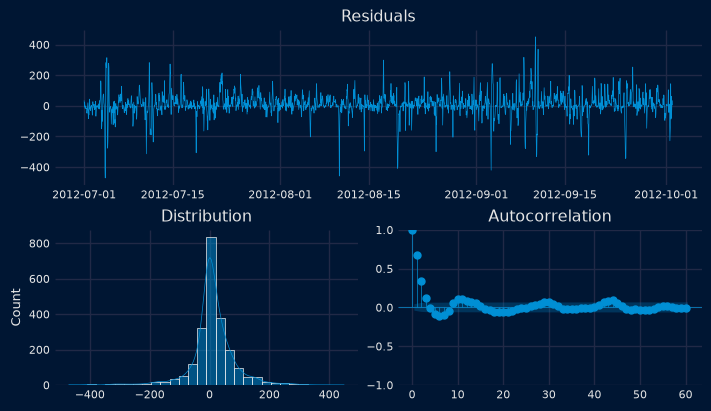

In [15]:
# Out-of-sample residuals distribution
# ==============================================================================
residuals = data.loc[predictions_val.index, 'users'] - predictions_val['pred']
print(pd.Series(np.where(residuals < 0, 'negative', 'positive')).value_counts())
print(f"Mean of the residuals   : {residuals.mean():.2f}")
print(f"Median of the residuals : {residuals.median():.2f}")
_ = plot_residuals(residuals=residuals, figsize=(7, 4))

The out-of-sample residuals are not centered at zero: both the mean (10.57) and the median (4.81) are positive, which means that the model tends to underestimate the number of users in the validation period. Since bootstrapping adds these residuals to the predictions, the intervals will be shifted upwards.

The autocorrelation plot also shows that consecutive residuals are correlated (0.67 at lag 1). Bootstrapping samples residuals independently, so this dependence is not explicitly reproduced in the intervals. It is also a sign that the model has not fully captured the short-term dynamics of the series.

With the [`set_out_sample_residuals()`](https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.set_out_sample_residuals) method, the out-of-sample residuals are stored in the forecaster object so that they can be used to calibrate the prediction intervals.

In [16]:
# Store out-of-sample residuals in the forecaster
# ==============================================================================
forecaster.set_out_sample_residuals(
    y_true = data.loc[predictions_val.index, 'users'], 
    y_pred = predictions_val['pred']
)

Now that the new residuals have been added to the forecaster, the prediction intervals can be calculated using `use_in_sample_residuals = False`.

In [17]:
# Backtesting with prediction intervals in test data using out-of-sample residuals
# ==============================================================================
metric, predictions = backtesting_forecaster(
                          forecaster              = forecaster,
                          y                       = data['users'],
                          exog                    = data[exog_features],
                          cv                      = cv_test,
                          metric                  = 'mean_absolute_error',
                          interval                = [0.1, 0.9],  # 80% prediction interval
                          interval_method         = 'bootstrapping',
                          n_boot                  = 150,
                          use_in_sample_residuals = False,  # Use out-of-sample residuals
                          use_binned_residuals    = False
                      )
predictions.head(5)

100%|██████████| 19/19 [00:00<00:00, 80.60it/s]

,fold,pred,lower_bound,upper_bound
2012-10-02 00:00:00,0,59.806858,31.578561,131.861512
2012-10-02 01:00:00,0,18.736429,-7.495726,136.241295
2012-10-02 02:00:00,0,8.343854,-23.354319,140.180018
2012-10-02 03:00:00,0,5.829008,-31.866659,155.701510
2012-10-02 04:00:00,0,9.904088,-15.493223,199.970098


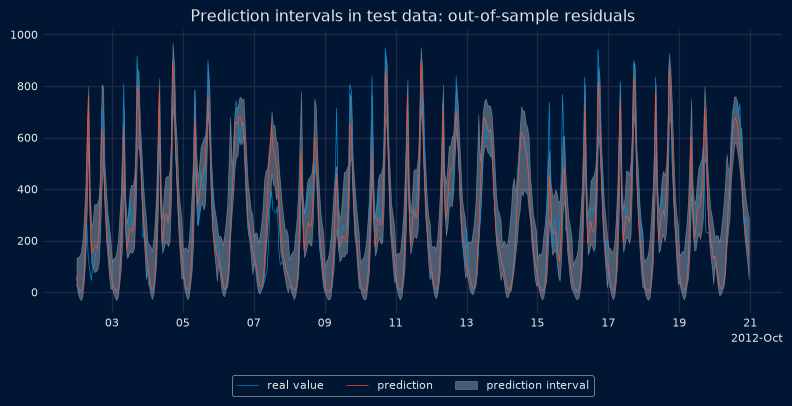

Empirical coverage of the interval: 83.11 %
Area of the interval: 100660.88
Winkler score: 311.36


In [18]:
# Plot intervals
# ==============================================================================
fig, ax = plt.subplots(figsize=(8.5, 3.5))
plot_prediction_intervals(
    predictions         = predictions,
    y_true              = data_test,
    target_variable     = "users",
    title               = "Prediction intervals in test data: out-of-sample residuals",
    ax                  = ax,
    kwargs_fill_between = {'color': 'white', 'alpha': 0.3, 'zorder': 1}
)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3)
plt.show()

# Coverage, area and Winkler score of the intervals (on test data)
# ==============================================================================
evaluate_predicted_intervals(predictions=predictions, y_true=data_test['users'])

The prediction intervals derived from the out-of-sample residuals are considerably wider than those based on the in-sample residuals, and the empirical coverage (83.1%) is now close to the nominal coverage (80%). However, the Winkler score barely changes (from 310 to 311): what is gained in coverage is lost in sharpness.

The zoomed view of one week below shows that the intervals have a similar width regardless of the predicted value, because all the residuals are sampled from a single pool. As a result, the intervals are excessively wide when the number of users is low (night hours), and they may be too narrow around the peaks of demand. The next section shows how to make the width of the interval depend on the predicted value.

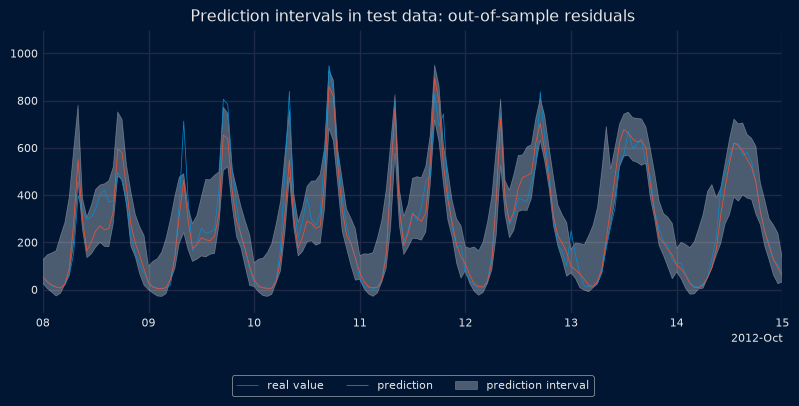

In [19]:
# Plot intervals zoomed in on one week of the test set
# ==============================================================================
fig, ax = plt.subplots(figsize=(8.5, 3.5))
plot_prediction_intervals(
    predictions         = predictions,
    y_true              = data_test,
    target_variable     = "users",
    initial_x_zoom      = zoom_window,
    title               = "Prediction intervals in test data: out-of-sample residuals",
    ax                  = ax,
    kwargs_fill_between = {'color': 'white', 'alpha': 0.3, 'zorder': 1}
)
ax.set_ylim(ylim_zoom)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3)
plt.show()

In [20]:
# Store results for later comparison
# ==============================================================================
predictions_out_sample_residuals = predictions.copy()

## Intervals conditioned on predicted values (binned residuals)

The bootstrapping process described so far assumes that the residuals are independent and identically distributed (i.i.d.) and, in particular, that their distribution does not depend on the predicted value (constant variance), so that any residual can be added to any prediction. In reality, this is rarely true; in most cases, the magnitude of the residuals is correlated with the magnitude of the predicted value. In this case, for example, one would hardly expect the error to be the same when the predicted number of users is close to zero as when it is in the hundreds.

To account for the dependence between the residuals and the predicted values, skforecast can **partition the residuals into *K* bins**, where each bin is associated with a range of predicted values. Using this strategy, the bootstrapping process samples the residuals from different bins depending on the predicted value, which can improve the coverage of the interval while adjusting the width if necessary, allowing the model to **better distribute the uncertainty of its predictions**.

Internally, skforecast uses a [`QuantileBinner`](https://skforecast.org/latest/api/preprocessing#skforecast.preprocessing._preprocessing.QuantileBinner) class to bin data into quantile-based bins using `numpy.percentile`. This class is similar to [`KBinsDiscretizer`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.KBinsDiscretizer.html) but faster for binning data into quantile-based bins. Bin intervals are defined following the convention: `bins[i-1] <= x < bins[i]`. The binning process can be adjusted using the `binner_kwargs` argument of the forecaster.

The number of bins is a hyperparameter. A higher number of bins allows the intervals to adapt better to the predicted value, but fewer residuals are available in each bin, so the estimation of the quantiles becomes noisier. By default, 10 bins are used (`binner_kwargs={'n_bins': 10}`); in this example, 15 bins are used. If the number of bins is tuned, it must be done using validation data, never the test set.

In [21]:
# Create and train forecaster
# ==============================================================================
forecaster = ForecasterRecursive(
                 estimator         = LGBMRegressor(**params),
                 lags              = lags,
                 window_features   = window_features,
                 calendar_features = calendar_transformer,
                 binner_kwargs     = {'n_bins': 15}
             )

forecaster.fit(
    y    = data.loc[:end_validation, 'users'],
    exog = data.loc[:end_validation, exog_features],
    store_in_sample_residuals = True
)

During the training process, the forecaster uses the in-sample predictions to define intervals (bins). Residuals are then assigned to these bins based on their corresponding predicted values. The limits of each bin are stored in the `binner_intervals_` attribute. For example, if the bin "0" has an interval of (-2.06, 7.34), it means that it will store the residuals of the predictions that fall within that interval. Predictions below the lower limit of the first bin or above the upper limit of the last bin are assigned to the first or last bin, respectively.

When the prediction intervals are calculated, the residuals are sampled from the bin corresponding to the predicted value. This way, the model can adjust the width of the intervals depending on the predicted value, which can help to better distribute the uncertainty of the predictions.

Although not used in this example, the in-sample residuals are also divided into bins and stored in the `in_sample_residuals_by_bin_` attribute.

In [22]:
# Intervals of the residual bins
# ==============================================================================
pprint(forecaster.binner_intervals_)

{0: (-2.058499067584011, 7.339683335728002),
 1: (7.339683335728002, 15.786737846689995),
 2: (15.786737846689995, 30.53493920944861),
 3: (30.53493920944861, 59.12817141401169),
 4: (59.12817141401169, 90.53042339424537),
 5: (90.53042339424537, 120.3837770378804),
 6: (120.3837770378804, 151.12755002609902),
 7: (151.12755002609902, 178.99957394146344),
 8: (178.99957394146344, 209.83991808145416),
 9: (209.83991808145416, 247.60669961894214),
 10: (247.60669961894214, 289.299070321893),
 11: (289.299070321893, 338.21124164842377),
 12: (338.21124164842377, 415.7439121230614),
 13: (415.7439121230614, 524.3743996547786),
 14: (524.3743996547786, 963.2802014321065)}


In [23]:
# Number of in-sample residuals by bin
# ==============================================================================
for k, v in forecaster.in_sample_residuals_by_bin_.items():
    print(f"Bin {k}: n={len(v)}")

Bin 0: n=666
Bin 1: n=666
Bin 2: n=666
Bin 3: n=666
Bin 4: n=666
Bin 5: n=666
Bin 6: n=666
Bin 7: n=666
Bin 8: n=666
Bin 9: n=666
Bin 10: n=666
Bin 11: n=666
Bin 12: n=666
Bin 13: n=666
Bin 14: n=666


The [`set_out_sample_residuals()`](https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.set_out_sample_residuals) method will bin the residuals according to the intervals learned during fitting. To avoid using too much memory, the number of residuals stored per bin is limited to `10_000 // n_bins` (666 residuals per bin in this example). The predictions obtained in the backtesting on the validation set are used.

In [24]:
# Store out-of-sample residuals in the forecaster
# ==============================================================================
forecaster.set_out_sample_residuals(
    y_true = data.loc[predictions_val.index, 'users'], 
    y_pred = predictions_val['pred']
)

In [25]:
# Number of out-of-sample residuals by bin
# ==============================================================================
for k, v in forecaster.out_sample_residuals_by_bin_.items():
    print(f"Bin {k}: n={len(v)}")

Bin 0: n=62
Bin 1: n=154
Bin 2: n=97
Bin 3: n=153
Bin 4: n=91
Bin 5: n=73
Bin 6: n=95
Bin 7: n=111
Bin 8: n=88
Bin 9: n=163
Bin 10: n=185
Bin 11: n=203
Bin 12: n=199
Bin 13: n=241
Bin 14: n=317


The number of out-of-sample residuals is very different from one bin to another. The bins are defined with the quantiles of the in-sample predictions, so they contain the same number of in-sample residuals, but the predictions of the validation period are not evenly distributed among them. The least populated bin contains 62 residuals, which is enough to estimate the 10th and 90th percentiles, but it illustrates the practical limit when increasing the number of bins: the more bins, the fewer residuals are available to estimate the quantiles of each one.

As a rule of thumb, keep an average of at least 10 residuals per bin. Below that, the intervals tend to be too narrow, and `set_out_sample_residuals()` issues a `ResidualsUsageWarning`. With a short validation set, reduce `n_bins` in `binner_kwargs` or use `use_binned_residuals=False`.

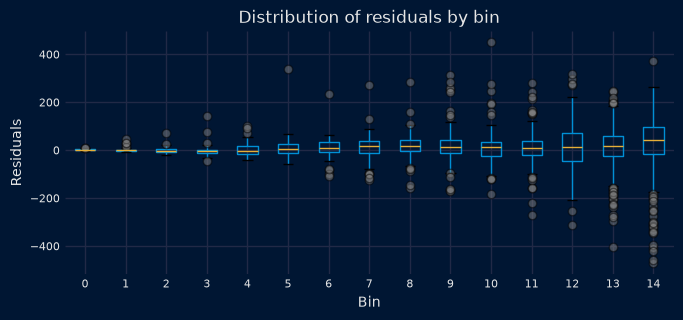

In [26]:
# Distribution of the residuals by bin
# ==============================================================================
out_sample_residuals_by_bin_df = pd.DataFrame(
    {k: pd.Series(v) for k, v in forecaster.out_sample_residuals_by_bin_.items()}
)
fig, ax = plt.subplots(figsize=(7, 3))
out_sample_residuals_by_bin_df.boxplot(
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=6, alpha=0.5),
    ax=ax
)
ax.set_title("Distribution of residuals by bin", fontsize=12)
ax.set_xlabel("Bin", fontsize=10)
ax.set_ylabel("Residuals", fontsize=10)
plt.show()

The box plots show how the spread and magnitude of the residuals differ depending on the predicted value. The residuals are higher and more dispersed when the predicted value is higher (higher bin), which is consistent with the intuition that errors tend to be larger when the predicted value is larger. Most bins also have a positive mean residual (see the summary table below), which reflects the same underestimation bias observed in the global distribution of the out-of-sample residuals.

In [27]:
# Summary information of bins
# ==============================================================================
bins_summary = out_sample_residuals_by_bin_df.describe().T
bins_summary.index.name = 'bin'
bins_summary.insert(0, 'interval', bins_summary.index.map(forecaster.binner_intervals_))
bins_summary['interval'] = bins_summary['interval'].apply(lambda x: np.round(x, 2))
bins_summary

,interval,count,mean,std,min,25%,50%,75%,max
bin,,,,,,,,,
0,"[-2.06, 7.34]",62.0,1.323739,3.347242,-4.344465,-1.259973,0.967387,3.325592,10.696952
1,"[7.34, 15.79]",154.0,0.279240,6.640277,-8.765945,-3.513490,-0.987068,1.924822,46.118619
2,"[15.79, 30.53]",97.0,-0.265793,12.317799,-20.991691,-8.091929,-2.404640,5.062957,71.615914
3,"[30.53, 59.13]",153.0,-3.551069,17.861359,-44.938411,-12.858413,-5.399200,2.021401,144.221783
4,"[59.13, 90.53]",91.0,2.468340,27.065248,-41.798786,-15.472666,-4.347441,16.084610,102.192538
5,"[90.53, 120.38]",73.0,10.643658,47.842949,-56.812480,-13.474935,4.883647,25.821022,339.788475
6,"[120.38, 151.13]",95.0,8.612300,40.845478,-105.853842,-8.842125,8.037872,33.710405,235.907866
7,"[151.13, 179.0]",111.0,12.843652,48.112488,-124.015632,-9.952662,16.766075,36.337500,271.643575
8,"[179.0, 209.84]",88.0,17.021465,57.339997,-159.379665,-4.485558,18.808255,40.227259,283.611050


Finally, the prediction intervals are estimated again, this time using out-of-sample residuals conditioned on the predicted values.

In [28]:
# Backtesting with prediction intervals in test data using out-of-sample binned residuals
# ==============================================================================
metric, predictions = backtesting_forecaster(
                          forecaster              = forecaster,
                          y                       = data['users'],
                          exog                    = data[exog_features],
                          cv                      = cv_test,
                          metric                  = 'mean_absolute_error',
                          interval                = [0.1, 0.9],  # 80% prediction interval
                          interval_method         = 'bootstrapping',
                          n_boot                  = 150,
                          use_in_sample_residuals = False,  # Use out-of-sample residuals
                          use_binned_residuals    = True    # Residuals conditioned on predicted values
                      )
predictions.head(5)

100%|██████████| 19/19 [00:00<00:00, 71.70it/s]

,fold,pred,lower_bound,upper_bound
2012-10-02 00:00:00,0,59.806858,29.467702,89.647428
2012-10-02 01:00:00,0,18.736429,6.098207,43.457271
2012-10-02 02:00:00,0,8.343854,4.542673,18.806828
2012-10-02 03:00:00,0,5.829008,3.469681,12.562592
2012-10-02 04:00:00,0,9.904088,5.203550,17.719854


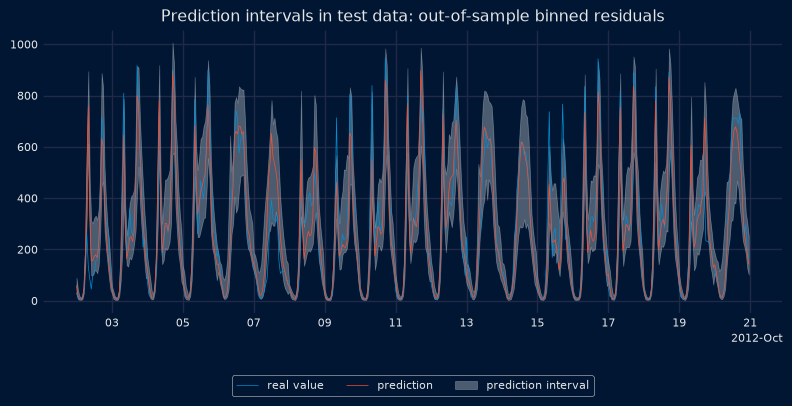

Empirical coverage of the interval: 86.4 %
Area of the interval: 96776.35
Winkler score: 266.75


In [29]:
# Plot intervals
# ==============================================================================
fig, ax = plt.subplots(figsize=(8.5, 3.5))
plot_prediction_intervals(
    predictions         = predictions,
    y_true              = data_test,
    target_variable     = "users",
    title               = "Prediction intervals in test data: out-of-sample binned residuals",
    ax                  = ax,
    kwargs_fill_between = {'color': 'white', 'alpha': 0.3, 'zorder': 1}
)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3)
plt.show()

# Coverage, area and Winkler score of the intervals (on test data)
# ==============================================================================
evaluate_predicted_intervals(predictions=predictions, y_true=data_test['users'])

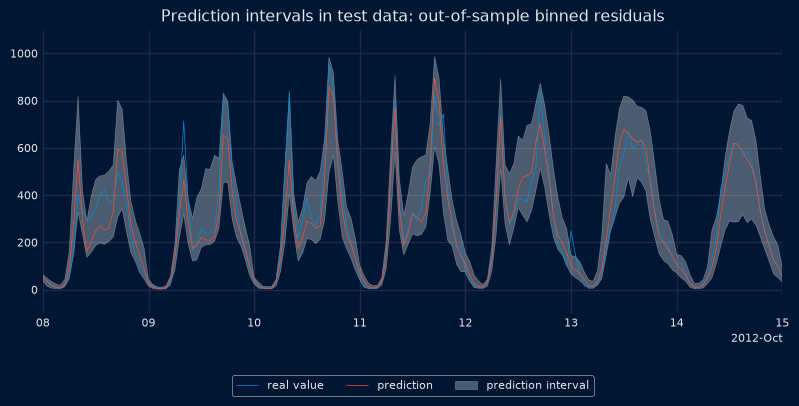

In [30]:
# Plot intervals zoomed in on one week of the test set
# ==============================================================================
fig, ax = plt.subplots(figsize=(8.5, 3.5))
plot_prediction_intervals(
    predictions         = predictions,
    y_true              = data_test,
    target_variable     = "users",
    initial_x_zoom      = zoom_window,
    title               = "Prediction intervals in test data: out-of-sample binned residuals",
    ax                  = ax,
    kwargs_fill_between = {'color': 'white', 'alpha': 0.3, 'zorder': 1}
)
ax.set_ylim(ylim_zoom)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3)
plt.show()

In [31]:
# Store results for later comparison
# ==============================================================================
predictions_out_sample_residuals_binned = predictions.copy()

When using out-of-sample residuals conditioned on the predicted value, the uncertainty is distributed differently: the intervals are narrow when the predicted number of users is low and wide when it is high. Compared with the non-binned out-of-sample residuals, the area is reduced by around 4% (from 100,661 to 96,776) and the Winkler score improves from 311 to 267. The empirical coverage (86.4%) is above the nominal coverage (80%), which means that the estimated intervals are conservative.

One possible reason for this conservative behavior is that the out-of-sample residuals are obtained with a model trained only with the training partition, and they show a positive bias in the validation period. The final model, trained with the training and validation data, is expected to have smaller errors, so these residuals slightly overstate its uncertainty.

The following plot compares, over the same week of the test set, the prediction intervals obtained using in-sample residuals, out-of-sample residuals, and out-of-sample residuals conditioned on the predicted values. The three panels share the y-axis, and the coverage shown in each title is computed on the whole test set.

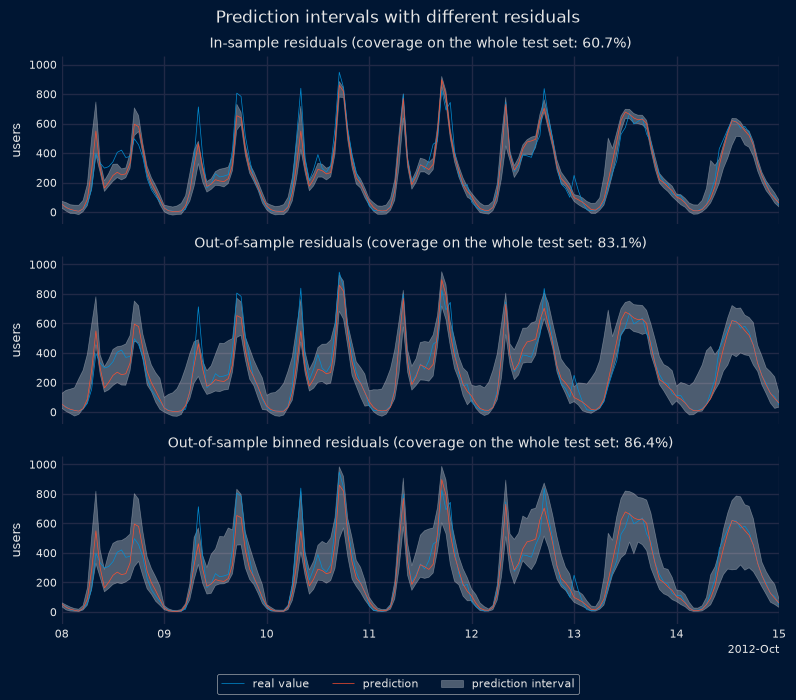

In [32]:
# Plot intervals using: in-sample residuals, out-of-sample residuals and binned residuals
# ==============================================================================
methods = {
    'In-sample residuals': predictions_in_sample_residuals,
    'Out-of-sample residuals': predictions_out_sample_residuals,
    'Out-of-sample binned residuals': predictions_out_sample_residuals_binned
}

fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(8, 7), sharex=True, sharey=True)
for ax, (name, pred) in zip(axs, methods.items()):
    coverage = calculate_coverage(
                   y_true      = data_test['users'],
                   lower_bound = pred['lower_bound'],
                   upper_bound = pred['upper_bound']
               )
    plot_prediction_intervals(
        predictions         = pred,
        y_true              = data_test,
        target_variable     = "users",
        initial_x_zoom      = zoom_window,
        title               = f"{name} (coverage on the whole test set: {100 * coverage:.1f}%)",
        yaxis_title         = "users",
        ax                  = ax,
        kwargs_fill_between = {'color': 'white', 'alpha': 0.3, 'zorder': 1}
    )
    ax.title.set_fontsize(10)
    ax.get_legend().remove()

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3)
fig.suptitle("Prediction intervals with different residuals", fontsize=12)
fig.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

The global coverage does not tell the whole story. A good interval should achieve the nominal coverage not only on average, but also for the different levels of demand. To verify it, the test predictions are divided into three groups of equal size according to the predicted number of users (low, medium and high), and the empirical coverage and the mean width of the intervals are calculated for each group.

In [33]:
# Coverage and width of the intervals conditioned on the predicted value
# ==============================================================================
def conditional_coverage(predictions: pd.DataFrame, y_true: pd.Series) -> pd.DataFrame:
    """
    Coverage (%) and mean width of the intervals in three groups of equal size,
    defined by the quantiles of the predicted value.
    """
    inside = y_true.between(predictions['lower_bound'], predictions['upper_bound'])
    width = predictions['upper_bound'] - predictions['lower_bound']
    groups = pd.qcut(predictions['pred'], q=3, precision=0)
    results = pd.DataFrame({
                  'coverage (%)': 100 * inside.groupby(groups, observed=True).mean(),
                  'mean width': width.groupby(groups, observed=True).mean()
              })
    results.index.name = 'Predicted users'

    return results


conditional_results = pd.concat(
    {
        name: conditional_coverage(pred, data_test['users'])
        for name, pred in methods.items()
    },
    axis=1
)
conditional_results.round(1)

In-sample residuals            Out-of-sample residuals  \
                       coverage (%) mean width            coverage (%)   
Predicted users                                                          
(3.0, 143.0]                   88.8       73.1                    89.5   
(143.0, 332.0]                 56.6       96.2                    92.1   
(332.0, 897.0]                 36.8      113.4                    67.8   

                           Out-of-sample binned residuals             
                mean width                   coverage (%) mean width  
Predicted users                                                       
(3.0, 143.0]         207.9                           83.6       71.1  
(143.0, 332.0]       227.3                           88.8      224.2  
(332.0, 897.0]       227.0                           86.8      341.4

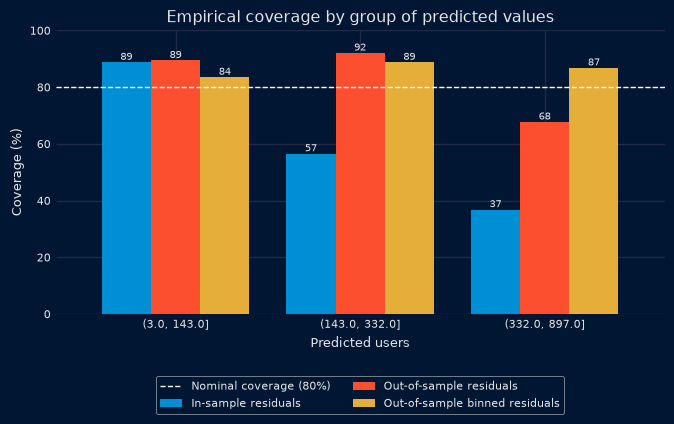

In [34]:
# Plot coverage by group of predicted values
# ==============================================================================
coverage_by_group = conditional_results.xs('coverage (%)', axis=1, level=1)

fig, ax = plt.subplots(figsize=(7, 3.5))
coverage_by_group.plot.bar(ax=ax, rot=0, width=0.8)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=7)
ax.axhline(80, color='white', linestyle='--', linewidth=1, label='Nominal coverage (80%)')
ax.set_ylim(0, 100)
ax.set_xlabel('Predicted users')
ax.set_ylabel('Coverage (%)')
ax.set_title('Empirical coverage by group of predicted values')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2)
plt.show()

The table and the bar chart make the progression between the three approaches explicit:

+ **In-sample residuals**: the coverage collapses as the predicted value increases, from 88.8% in the group of low predictions to 36.8% in the group of high predictions. The intervals are too narrow precisely where the errors of the model are larger.

+ **Out-of-sample residuals**: the global coverage of 83.1% is the average of two opposite errors. The intervals have a mean width of more than 200 users in all the groups, which is excessive for the low predictions and insufficient for the high ones, where the coverage only reaches 67.8%.

+ **Out-of-sample binned residuals**: the coverage is similar in the three groups (83.6%, 88.8% and 86.8%) and the width of the intervals grows with the predicted value, from 71 to 341 users.

Therefore, using out-of-sample residuals corrects the global calibration of the intervals, and conditioning them on the predicted value corrects where the uncertainty is placed.

<div class="admonition note" name="html-admonition" style="background: rgba(255,145,0,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #ff9100; border-color: #ff9100; padding-left: 10px; padding-right: 10px">

<p class="title">
    <i style="font-size: 18px; color:#ff9100; border-color: #ff9100;"></i>
    <b style="color: #ff9100;"> <span style="color: #ff9100;">&#9888;</span> Warning</b>
</p>

<p>
<b>Probabilistic forecasting in production</b>

The correct estimation of prediction intervals with bootstrapped residuals depends on the residuals being representative of future errors. For this reason, out-of-sample residuals should be used. However, the dynamics of the series and models can change over time, so it is important to monitor and regularly update the residuals. It can be done easily using the <a href="https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.set_out_sample_residuals"><code>set_out_sample_residuals()</code></a> method.
</p>

</div>

## Prediction of multiple intervals

The [`backtesting_forecaster`](https://skforecast.org/latest/api/model_selection#skforecast.model_selection._validation.backtesting_forecaster) function supports estimating multiple quantiles in a single run, from which prediction intervals at different coverage levels can be constructed. This is useful for assessing interval quality across a range of probabilities, and comes at almost no additional computational cost compared to estimating a single interval.

In the following example, a set of quantiles is estimated via backtesting and used to build prediction intervals at nominal coverage levels of 10%, 20%, 30%, 40%, 50%, 60%, 70%, 80%, 90% and 95%. The empirical coverage and the area of each interval are then measured against the test data.

In [35]:
# Prediction of multiple quantiles
# ==============================================================================
quantiles = [
    0.025, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60,
    0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.975
]
metric, predictions = backtesting_forecaster(
                          forecaster              = forecaster,
                          y                       = data['users'],
                          exog                    = data[exog_features],
                          cv                      = cv_test,
                          metric                  = 'mean_absolute_error',
                          interval                = quantiles,
                          interval_method         = 'bootstrapping',
                          n_boot                  = 150,
                          use_in_sample_residuals = False,  # Use out-of-sample residuals
                          use_binned_residuals    = True    # Residuals conditioned on predicted values
                      )
predictions.head()

100%|██████████| 19/19 [00:00<00:00, 81.07it/s]

,fold,pred,q_0.025,q_0.05,q_0.1,q_0.15,q_0.2,q_0.25,q_0.3,q_0.35,...,q_0.55,q_0.6,q_0.65,q_0.7,q_0.75,q_0.8,q_0.85,q_0.9,q_0.95,q_0.975
2012-10-02 00:00:00,0,59.806858,21.394854,24.753867,29.467702,37.208407,40.160613,44.006751,46.109929,50.144769,...,61.676650,69.842802,71.116587,73.430910,76.556363,78.404018,83.305776,89.647428,101.135168,119.594460
2012-10-02 01:00:00,0,18.736429,3.823246,4.428840,6.098207,7.258918,7.725225,10.062596,11.331109,12.543273,...,19.587360,21.750654,22.426858,25.942015,30.120835,34.927024,38.594785,43.457271,61.588106,98.180927
2012-10-02 02:00:00,0,8.343854,2.589883,3.199794,4.542673,5.256008,5.728307,6.035306,7.036289,7.580606,...,9.537155,10.481016,11.073380,12.040345,12.825298,14.228836,16.807480,18.806828,26.983981,47.329914
2012-10-02 03:00:00,0,5.829008,2.284566,2.598515,3.469681,3.758989,4.273794,4.617065,5.109465,5.570610,...,7.352128,7.582263,8.050841,8.665297,9.176679,9.753946,11.335291,12.562592,15.071611,17.257213
2012-10-02 04:00:00,0,9.904088,3.389574,4.603494,5.203550,6.004520,7.163223,7.718639,8.018983,8.336490,...,10.356019,10.974005,11.592354,12.082498,13.292125,14.722783,15.853279,17.719854,18.651374,26.036931


In [36]:
# Calculate coverage and area for each interval
# ==============================================================================
intervals = [
    [0.025, 0.975], [0.05, 0.95], [0.10, 0.90], [0.15, 0.85], [0.20, 0.80],
    [0.25, 0.75], [0.30, 0.70], [0.35, 0.65], [0.40, 0.60], [0.45, 0.55]
]
nominal_coverages = [100 * (upper_q - lower_q) for lower_q, upper_q in intervals]
observed_coverages = []
observed_areas = []
for lower_q, upper_q in intervals:
    lower_bound = predictions[f'q_{lower_q}']
    upper_bound = predictions[f'q_{upper_q}']
    observed_coverage = calculate_coverage(
                            y_true      = data_test['users'],
                            lower_bound = lower_bound,
                            upper_bound = upper_bound
                        )
    observed_coverages.append(100 * observed_coverage)
    observed_areas.append((upper_bound - lower_bound).sum())

results = pd.DataFrame({
              'Interval': intervals,
              'Nominal coverage (%)': nominal_coverages,
              'Observed coverage (%)': observed_coverages,
              'Area': observed_areas
          })
results.round(2)

,Interval,Nominal coverage (%),Observed coverage (%),Area
0,"[0.025, 0.975]",95.0,96.27,160756.57
1,"[0.05, 0.95]",90.0,93.64,131115.55
2,"[0.1, 0.9]",80.0,86.40,96776.35
3,"[0.15, 0.85]",70.0,80.48,75580.06
4,"[0.2, 0.8]",60.0,69.96,59399.98
5,"[0.25, 0.75]",50.0,59.87,46079.68
6,"[0.3, 0.7]",40.0,47.59,34936.25
7,"[0.35, 0.65]",30.0,36.18,25362.27
8,"[0.4, 0.6]",20.0,23.90,16575.47
9,"[0.45, 0.55]",10.0,12.28,8215.91


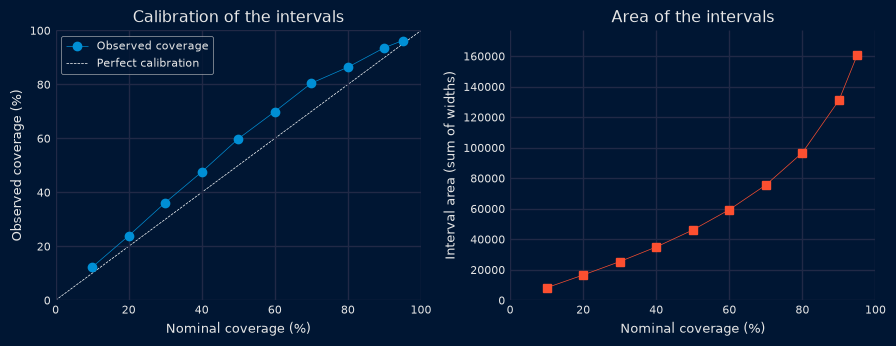

In [37]:
# Plot coverage and area for different intervals
# ==============================================================================
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 3.5))

# Calibration curve: observed coverage vs nominal coverage
axs[0].plot(
    results['Nominal coverage (%)'], results['Observed coverage (%)'], 'o-',
    label='Observed coverage'
)
axs[0].plot([0, 100], [0, 100], '--', c='white', zorder=0, label='Perfect calibration')
axs[0].set_xlim(0, 100)
axs[0].set_ylim(0, 100)
axs[0].set_xlabel('Nominal coverage (%)')
axs[0].set_ylabel('Observed coverage (%)')
axs[0].set_title('Calibration of the intervals')
axs[0].legend(loc='upper left')

# Area of the intervals
axs[1].plot(results['Nominal coverage (%)'], results['Area'], 's-', c='C1')
axs[1].set_xlim(0, 100)
axs[1].set_ylim(0, max(results['Area']) * 1.1)
axs[1].set_xlabel('Nominal coverage (%)')
axs[1].set_ylabel('Interval area (sum of widths)')
axs[1].set_title('Area of the intervals')

fig.tight_layout()
plt.show()

For all the nominal levels, the observed coverage is higher than the nominal coverage: the calibration curve (left panel) lies above the diagonal (for example, 86.4% for the 80% interval and 59.9% for the 50% interval). This confirms that the intervals estimated with out-of-sample binned residuals are conservative across the whole distribution, not only for a particular interval. As expected, the area grows with the nominal coverage (right panel), and it does so at an accelerating rate: wider intervals are the price of capturing a higher proportion of the observations. The plot is useful for selecting the most appropriate interval for a specific problem, balancing the desired coverage with the acceptable width of the intervals.

## Predict bootstrap, interval, quantile and distribution

The previous sections have demonstrated the use of the backtesting process to estimate the prediction interval over a given period of time. The goal is to mimic the behavior of the model in production by running predictions at regular intervals, incrementally updating the input data.

Skforecast also supports generating a single probabilistic forecast *N* steps ahead, without running a full backtesting loop, through four dedicated methods: [`predict_bootstrapping`](https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.predict_bootstrapping), [`predict_interval`](https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.predict_interval), [`predict_quantiles`](https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.predict_quantiles), and [`predict_dist`](https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.predict_dist).

When using [`backtesting_forecaster()`](https://skforecast.org/latest/api/model_selection#skforecast.model_selection._validation.backtesting_forecaster) to evaluate these prediction types, the output is controlled by the `interval` argument:

- `list` or `tuple`: A sequence of quantiles to compute, each value must be between 0 and 1. For example, `interval = [0.025, 0.975]` produces a 95% prediction interval, while `interval = [0.1, 0.5, 0.9]` returns three quantiles.

- `'bootstrapping'` (str): Returns the `n_boot` bootstrapped predictions of each step (one column per bootstrapping iteration), equivalent to `predict_bootstrapping`.

- `scipy.stats` **distribution object**: Fits the specified distribution to the bootstrapped predictions of each step and returns its parameters, equivalent to `predict_dist`.

<div class="admonition note" name="html-admonition" style="background: rgba(0,191,191,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00bfa5; border-color: #00bfa5; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00bfa5;"></i>
    <b style="color: #00bfa5;">&#128161; Tip</b>
</p>

All of these methods can be used either with in-sample or out-of-sample residuals using the <code>use_in_sample_residuals</code> argument, and with binned intervals conditioned on predicted values using the <code>use_binned_residuals</code> argument.

</div>

**Predict Bootstrapping** 

The [`predict_bootstrapping`](https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.predict_bootstrapping) method performs the `n_boot` bootstrapping iterations that generate the alternative prediction paths. These are the underlying values used to compute the intervals, quantiles, and distributions.

The examples in this section reuse the forecaster trained in the binned residuals section (15 bins, out-of-sample residuals stored with `set_out_sample_residuals()`). The arguments `use_in_sample_residuals=False` and `use_binned_residuals=True` are passed explicitly so that the predictions are generated with the out-of-sample residuals conditioned on the predicted value. With the default value `use_in_sample_residuals=True`, the overconfident in-sample residuals would be used instead.

In [38]:
# Predict 25 different forecasting sequences of 7 steps each using bootstrapping
# ==============================================================================
boot_predictions = forecaster.predict_bootstrapping(
                       steps                   = 7,
                       exog                    = data_test[exog_features],
                       n_boot                  = 25,
                       use_in_sample_residuals = False,
                       use_binned_residuals    = True
                   )
boot_predictions

,pred_boot_0,pred_boot_1,pred_boot_2,pred_boot_3,pred_boot_4,pred_boot_5,pred_boot_6,pred_boot_7,pred_boot_8,pred_boot_9,...,pred_boot_15,pred_boot_16,pred_boot_17,pred_boot_18,pred_boot_19,pred_boot_20,pred_boot_21,pred_boot_22,pred_boot_23,pred_boot_24
2012-10-02 00:00:00,58.746839,53.607783,75.226574,70.030695,51.467058,88.357474,84.027089,88.439517,46.704426,129.585596,...,64.655846,69.842802,51.283045,88.357474,60.841375,75.226574,53.885674,81.966194,48.684061,94.307781
2012-10-02 01:00:00,33.824886,15.298071,29.032566,5.573322,12.264022,55.039469,12.110470,23.937602,15.758725,56.237248,...,18.476184,30.034392,32.367489,33.004947,12.399189,23.931396,31.156099,43.748468,24.546644,43.892395
2012-10-02 02:00:00,6.954767,4.027971,13.155261,8.123818,7.332592,20.582318,7.565941,16.060413,6.813599,35.069721,...,3.388720,16.571859,6.908307,2.837912,13.124792,8.310104,11.042715,10.851828,17.886719,9.318598
2012-10-02 03:00:00,16.247570,11.091046,12.173375,7.384206,6.978928,12.621274,6.195154,7.080857,9.353420,6.705855,...,3.432788,5.931489,9.744207,1.781149,10.544849,3.905330,6.972696,2.142998,5.016664,8.359552
2012-10-02 04:00:00,14.342410,10.020164,11.431620,14.146774,16.644899,15.140701,2.996877,9.544691,12.257564,7.341845,...,4.697796,56.022707,6.881572,8.990186,17.178110,8.730130,5.494690,7.082321,7.976359,17.465616
2012-10-02 05:00:00,43.642293,50.834120,28.080706,36.239991,73.131064,43.904383,48.206297,22.658637,50.049445,29.760894,...,41.035821,112.701380,42.474355,124.391553,53.382166,53.753635,41.085980,51.653294,42.585962,53.751962
2012-10-02 06:00:00,187.736174,242.108679,140.353348,233.798744,229.491012,209.409063,202.369229,91.951029,194.689090,121.768339,...,189.007083,232.997161,150.286309,333.275032,152.541498,215.517811,234.659469,201.114208,150.294110,119.134295


A ridge plot is a useful way to visualize the uncertainty of a forecasting model. The [`plot_prediction_distribution`](https://skforecast.org/latest/api/plot#skforecast.plot.plot.plot_prediction_distribution) function estimates a kernel density for each step using the bootstrapped predictions.

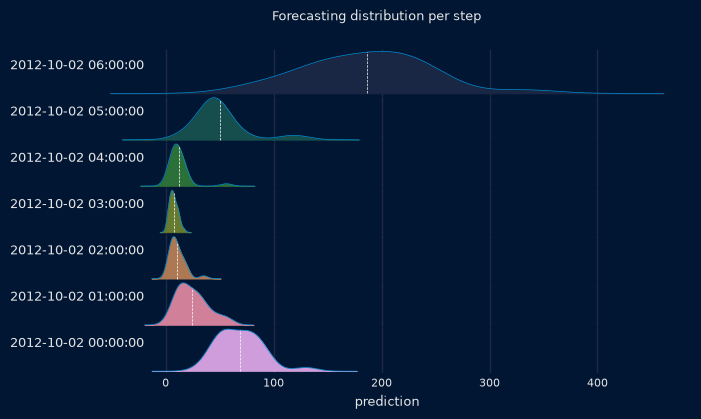

In [39]:
# Ridge plot of bootstrapping predictions
# ==============================================================================
_ = plot_prediction_distribution(boot_predictions, figsize=(7, 4))

Each distribution represents the uncertainty of one step of the forecast. The distributions of the night hours (01:00 to 04:00) are narrow and close to zero, while the distribution of 06:00, when the number of users starts to rise in the morning, is much wider. This is the effect of the binned residuals: each step samples residuals from the bin of its predicted value, and higher predictions fall in bins with larger residuals. Note that, with only 25 bootstrapping iterations, the estimated densities are rough; more iterations are needed to obtain smooth estimates.

**Predict Interval**

In most cases, the user is interested in a specific interval rather than the entire bootstrapping simulation matrix. To address this need, skforecast provides the [`predict_interval`](https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.predict_interval) method. This method internally uses [`predict_bootstrapping`](https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.predict_bootstrapping) to obtain the bootstrapping matrix and estimates the upper and lower quantiles for each step, thus providing the user with the desired prediction intervals.

In [40]:
# Predict intervals for next 7 steps, quantiles 0.1 and 0.9
# ==============================================================================
predictions = forecaster.predict_interval(
                  steps                   = 7,
                  exog                    = data_test[exog_features],
                  method                  = 'bootstrapping',
                  interval                = [0.1, 0.9],
                  n_boot                  = 150,
                  use_in_sample_residuals = False,
                  use_binned_residuals    = True
              )
predictions

,pred,lower_bound,upper_bound
2012-10-02 00:00:00,59.806858,34.971592,91.665964
2012-10-02 01:00:00,18.736429,6.923464,44.358214
2012-10-02 02:00:00,8.343854,3.902234,18.109711
2012-10-02 03:00:00,5.829008,3.687118,12.775221
2012-10-02 04:00:00,9.904088,5.233387,18.493545
2012-10-02 05:00:00,46.857429,28.517409,62.681856
2012-10-02 06:00:00,180.557002,140.005555,241.450088


<div class="admonition note" name="html-admonition" style="background: rgba(0,191,191,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00bfa5; border-color: #00bfa5; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00bfa5;"></i>
    <b style="color: #00bfa5;">&#128161; Tip</b>
</p>

The <a href="https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.predict_interval"><code>predict_interval</code></a> method can also be used to estimate the conformal prediction intervals using the argument <code>method = 'conformal'</code>. For more information, check out the following user guide:

<a href="../user_guides/probabilistic-forecasting-conformal-prediction.html" target="_blank"> Probabilistic Forecasting: Conformal Prediction </a>

</div>

**Predict Quantiles**

The [`predict_quantiles`](https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.predict_quantiles) method operates identically to [`predict_interval`](https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.predict_interval), with the added option to specify a list of quantiles to estimate at each step. These quantiles must be specified within the range of 0 to 1.

In [41]:
# Predict quantiles for next 7 steps, quantiles 5th, 25th, 75th and 95th
# ==============================================================================
predictions = forecaster.predict_quantiles(
                  steps                   = 7,
                  exog                    = data_test[exog_features],
                  quantiles               = [0.05, 0.25, 0.75, 0.95],
                  n_boot                  = 150,
                  use_in_sample_residuals = False,
                  use_binned_residuals    = True
              )
predictions

,q_0.05,q_0.25,q_0.75,q_0.95
2012-10-02 00:00:00,28.962582,40.304487,71.628653,105.790237
2012-10-02 01:00:00,4.503243,11.224777,31.416969,59.792451
2012-10-02 02:00:00,3.110316,6.210945,13.122431,31.340720
2012-10-02 03:00:00,2.860395,4.946754,9.424179,14.496785
2012-10-02 04:00:00,4.487580,7.899416,13.911139,20.613499
2012-10-02 05:00:00,26.667931,35.122910,52.156886,78.648324
2012-10-02 06:00:00,104.018032,162.835391,211.840003,285.247255


**Predict Distribution**

The intervals estimated so far are distribution-free, which means that no assumptions are made about a particular distribution. The [`predict_dist`](https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.predict_dist) method in skforecast allows fitting a parametric distribution to the bootstrapped prediction samples obtained with `predict_bootstrapping`. This is useful when there is reason to believe that the forecast errors follow a particular distribution, such as the normal distribution or Student's t-distribution. The `predict_dist` method allows the user to specify any continuous distribution from the [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html#continuous-distributions) module.

In [42]:
# Predict the parameters of a normal distribution for the next 7 steps
# ==============================================================================
predictions = forecaster.predict_dist(
                  steps                   = 7,
                  exog                    = data_test[exog_features],
                  distribution            = norm,
                  n_boot                  = 150,
                  use_in_sample_residuals = False,
                  use_binned_residuals    = True
              )
predictions

,loc,scale
2012-10-02 00:00:00,58.342409,26.162909
2012-10-02 01:00:00,23.597467,22.533441
2012-10-02 02:00:00,11.771049,11.336548
2012-10-02 03:00:00,8.007673,6.257920
2012-10-02 04:00:00,11.501834,5.323651
2012-10-02 05:00:00,47.517765,25.331130
2012-10-02 06:00:00,192.741602,65.354187


The output contains the parameters of the fitted distribution for each step. For the normal distribution, `loc` is the mean and `scale` is the standard deviation. These parameters can be used to compute any quantile, and therefore any prediction interval, with the `ppf` method (percent point function, the inverse of the cumulative distribution function) of the distribution. For example, the 80% prediction interval is obtained from the 0.1 and 0.9 quantiles.

Note that an interval derived from a normal distribution is always symmetric around the mean, whereas the distribution-free intervals obtained with `predict_interval` can be asymmetric (for example, when the number of users is close to zero and the errors cannot be negative beyond a certain value).

In [43]:
# 80% prediction interval from the parameters of the normal distribution
# ==============================================================================
interval_from_dist = pd.DataFrame(
    {
        'lower_bound': norm.ppf(0.1, loc=predictions['loc'], scale=predictions['scale']),
        'upper_bound': norm.ppf(0.9, loc=predictions['loc'], scale=predictions['scale'])
    },
    index=predictions.index
)
interval_from_dist

,lower_bound,upper_bound
2012-10-02 00:00:00,24.813291,91.871526
2012-10-02 01:00:00,-5.280300,52.475233
2012-10-02 02:00:00,-2.757322,26.299419
2012-10-02 03:00:00,-0.012174,16.027520
2012-10-02 04:00:00,4.679300,18.324367
2012-10-02 05:00:00,15.054615,79.980915
2012-10-02 06:00:00,108.986841,276.496363


Some lower bounds of the night hours are negative, which is impossible for a count of users. This is a consequence of imposing a symmetric normal distribution on errors that are skewed when the predicted value is close to zero. The distribution-free interval obtained with `predict_interval` for the same steps does not have this problem, which is why a parametric distribution should only be used when there is evidence that it fits the errors.

## Key takeaways

+ Bootstrapped residuals turn a point forecaster into a probabilistic one: many alternative prediction paths are simulated by adding resampled residuals to the predictions, and the intervals are the quantiles of those paths at each step.

+ In-sample residuals underestimate the error expected on new data and produce overconfident intervals (around 61% empirical coverage for an 80% nominal interval in this example).

+ Out-of-sample residuals, obtained by backtesting on a validation set that was not used to train the model that generated them, correct the global calibration of the intervals.

+ Conditioning the residuals on the predicted value (`use_binned_residuals=True`) places the uncertainty where it belongs: narrow intervals for low predictions and wide intervals for high predictions. Evaluating the coverage by groups of predicted values reveals problems that the global coverage hides.

+ The number of bins and the residuals themselves must be selected with validation data, never with the test set, and the residuals should be refreshed periodically in production.